# DCNN Depth Ablation (Multi-Channel)

This notebook runs three depth variants on the same fixed split using the same training settings.

- **Shallow**: 32 -> 64
- **Base**: 32 -> 64 -> 128 -> 256
- **Deep**: 32 -> 64 -> 128 -> 256 -> 512

Inputs are P + N + S + segm channels, outputs are Dw and rho.

In [1]:
from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# ------------------------------
# Global config
# ------------------------------
DATA_ROOT = Path("synthetic_runs1T_FK_2c")
TARGET_KEYS = ("Dw", "rho")
OUT_SHAPE = (96, 96, 96)

# Keep split fixed for fair comparison across random seeds
SPLIT_SEED = 42
SEEDS = [42, 123, 999]

EPOCHS = 120
BATCH_SIZE = 8
NUM_WORKERS = 0
LR = 1e-3
WEIGHT_DECAY = 1e-4

DEPTH_CONFIGS = {
    "shallow": [32, 64],
    "base": [32, 64, 128, 256],
    "deep": [32, 64, 128, 256, 512],
}

RUN_DIR = Path("runs/depth_ablation_multichannel_multiseed")
RUN_DIR.mkdir(parents=True, exist_ok=True)

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(SPLIT_SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "")
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("Seeds to run:", SEEDS)

Device: cuda NVIDIA GeForce RTX 5080
DATA_ROOT exists: True
Seeds to run: [42, 123, 999]


In [2]:
samples = sorted([p for p in DATA_ROOT.glob("synthetic1T_run*") if p.is_dir()])
print("Num samples:", len(samples))
print("First sample:", samples[0] if samples else None)

random.Random(SPLIT_SEED).shuffle(samples)
n = len(samples)
train = samples[:int(0.7*n)]
val   = samples[int(0.7*n):int(0.85*n)]
test  = samples[int(0.85*n):]
print("Split sizes:", len(train), len(val), len(test))

split_manifest = {
    "split_seed": SPLIT_SEED,
    "seeds": SEEDS,
    "train": [p.name for p in train],
    "val": [p.name for p in val],
    "test": [p.name for p in test],
}
(RUN_DIR / "split_manifest.json").write_text(json.dumps(split_manifest, indent=2))
print("Saved split manifest ->", RUN_DIR / "split_manifest.json")

Num samples: 250
First sample: synthetic_runs1T_FK_2c\synthetic1T_run100
Split sizes: 175 37 38
Saved split manifest -> runs\depth_ablation_multichannel_multiseed\split_manifest.json


In [3]:
def get_y(sample_dir):
    p = json.loads((sample_dir/"parameters.json").read_text())
    vals = []
    for k in TARGET_KEYS:
        v = float(p[k])
        if k == "Dw":
            v = np.log(v)
        vals.append(v)
    return np.array(vals, dtype=np.float32)

Y_train = np.stack([get_y(s) for s in train], axis=0)
Y_MEAN = Y_train.mean(axis=0)
Y_STD  = Y_train.std(axis=0) + 1e-6
print("Y_MEAN:", Y_MEAN)
print("Y_STD :", Y_STD)

Y_MEAN: [0.34416467 0.3797969 ]
Y_STD : [0.9162873  0.23868617]


In [4]:
def read_nii(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    return arr

def bbox_from_mask(mask, margin=12):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return None
    z0,y0,x0 = idx.min(axis=0)
    z1,y1,x1 = idx.max(axis=0) + 1
    z0 = max(z0 - margin, 0); y0 = max(y0 - margin, 0); x0 = max(x0 - margin, 0)
    z1 = min(z1 + margin, mask.shape[0]); y1 = min(y1 + margin, mask.shape[1]); x1 = min(x1 + margin, mask.shape[2])
    return (z0,z1,y0,y1,x0,x1)

def crop(arr, bb):
    z0,z1,y0,y1,x0,x1 = bb
    return arr[z0:z1, y0:y1, x0:x1]

def resize_3d(arr, out_shape=(96,96,96)):
    t = torch.from_numpy(arr)[None,None,...]
    t = F.interpolate(t, size=out_shape, mode="trilinear", align_corners=False)
    return t[0,0].numpy()

def normalize_channel(arr):
    m = arr.mean()
    s = arr.std()
    return (arr - m) / (s + 1e-6)

class TumorParamDatasetCached(Dataset):
    def __init__(self, sample_dirs, out_shape=(96,96,96), target_keys=("Dw","rho"), verbose=True):
        self.sample_dirs = sample_dirs
        self.out_shape = out_shape
        self.target_keys = target_keys

        self.cache = []
        if verbose:
            print(f"Caching {len(sample_dirs)} samples...")

        for i, sd in enumerate(self.sample_dirs):
            x, y = self._load_one(sd)
            self.cache.append((x, y))
            if verbose and (i+1) % 25 == 0:
                print(f"  cached {i+1}/{len(sample_dirs)}")

        if verbose:
            print("Caching done.")

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        return self.cache[idx]

    def _load_one(self, sd):
        params = json.loads((sd/"parameters.json").read_text())
        vals = []
        for k in self.target_keys:
            v = float(params[k])
            if k == "Dw":
                v = np.log(v)
            vals.append(v)

        y_raw = np.array(vals, dtype=np.float32)
        y_norm = (y_raw - Y_MEAN) / Y_STD
        y = torch.tensor(y_norm, dtype=torch.float32)

        segm = read_nii(sd/"segm.nii.gz")
        bb = bbox_from_mask(segm > 0, margin=12)

        chans = [
            read_nii(sd/"P.nii.gz"),
            read_nii(sd/"N.nii.gz"),
            read_nii(sd/"S.nii.gz"),
            (segm > 0).astype(np.float32),
        ]

        processed = []
        for c in chans:
            if bb is not None:
                c = crop(c, bb)
            c = resize_3d(c, self.out_shape)
            if np.unique(c).size > 2:
                c = normalize_channel(c)
            processed.append(c)

        x = torch.from_numpy(np.stack(processed, axis=0)).float()
        return x, y

In [5]:
class CNN3DRegressorDynamic(nn.Module):
    def __init__(self, in_channels, out_dim, channels):
        super().__init__()

        blocks = []
        c_in = in_channels
        for c_out in channels:
            blocks.extend([
                nn.Conv3d(c_in, c_out, 3, padding=1),
                nn.BatchNorm3d(c_out),
                nn.ReLU(inplace=True),
            ])
            if c_out != channels[-1]:
                blocks.append(nn.MaxPool3d(2))
            c_in = c_out

        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(channels[-1], 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.head(self.features(x))

def mae(pred, y):
    return (pred - y).abs().mean()

def denorm_preds(preds_norm, trues_norm):
    preds = preds_norm * Y_STD + Y_MEAN
    trues = trues_norm * Y_STD + Y_MEAN

    # Convert Dw back from log-space
    for i, k in enumerate(TARGET_KEYS):
        if k == "Dw":
            preds[:, i] = np.exp(preds[:, i])
            trues[:, i] = np.exp(trues[:, i])

    return preds, trues

def compute_metrics(preds, trues):
    out = {}
    for i, k in enumerate(TARGET_KEYS):
        err = preds[:, i] - trues[:, i]
        mae_i = float(np.abs(err).mean())
        rmse_i = float(np.sqrt((err**2).mean()))
        out[k] = {"MAE": mae_i, "RMSE": rmse_i}
    return out

In [6]:
def run_one_depth(depth_name, depth_channels, seed):
    print(f"\n===== Running SEED {seed} | {depth_name.upper()} ({depth_channels}) =====")

    set_global_seed(seed)
    seed_dir = RUN_DIR / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    train_ds = TumorParamDatasetCached(train, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)
    val_ds   = TumorParamDatasetCached(val,   out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)
    test_ds  = TumorParamDatasetCached(test,  out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

    model = CNN3DRegressorDynamic(in_channels=4, out_dim=len(TARGET_KEYS), channels=depth_channels).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = GradScaler()
    loss_fn = nn.MSELoss()

    best_val_mse = float("inf")
    best_state = None
    best_epoch = -1

    train_start = time.time()

    for epoch in range(1, EPOCHS+1):
        model.train()
        tr_loss = tr_mae = 0.0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with autocast():
                pred = model(x)
                loss = loss_fn(pred, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            tr_loss += loss.item()
            tr_mae += mae(pred.detach(), y).item()

        model.eval()
        va_loss = va_mae = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                with autocast():
                    pred = model(x)
                    loss = loss_fn(pred, y)
                va_loss += loss.item()
                va_mae += mae(pred, y).item()

        val_mse = va_loss / len(val_loader)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
            print(
                f"seed {seed} | {depth_name} | Epoch {epoch:03d} | train MSE {tr_loss/len(train_loader):.4f} MAE {tr_mae/len(train_loader):.4f} "
                f"| val MSE {val_mse:.4f} MAE {va_mae/len(val_loader):.4f} | best {best_val_mse:.4f} @ {best_epoch:03d}"
            )

    train_seconds = time.time() - train_start

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    preds_norm, trues_norm = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            pred = model(x).cpu().numpy()[0]
            preds_norm.append(pred)
            trues_norm.append(y.numpy()[0])

    preds_norm = np.array(preds_norm)
    trues_norm = np.array(trues_norm)
    preds, trues = denorm_preds(preds_norm, trues_norm)
    metrics = compute_metrics(preds, trues)

    # Save model checkpoint per depth and seed
    ckpt_path = seed_dir / f"model_{depth_name}.pt"
    torch.save({
        "model_state": model.state_dict(),
        "seed": seed,
        "depth_name": depth_name,
        "depth_channels": depth_channels,
        "target_keys": TARGET_KEYS,
        "out_shape": OUT_SHAPE,
        "y_mean": Y_MEAN,
        "y_std": Y_STD,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
        "train_seconds": train_seconds,
    }, ckpt_path)

    # Save per-depth predictions
    pred_df = pd.DataFrame({
        "sample": [s.name for s in test],
        "true_Dw": trues[:, 0],
        "pred_Dw": preds[:, 0],
        "true_rho": trues[:, 1],
        "pred_rho": preds[:, 1],
    })
    pred_path = seed_dir / f"predictions_{depth_name}.csv"
    pred_df.to_csv(pred_path, index=False)

    result = {
        "seed": int(seed),
        "depth": depth_name,
        "channels": str(depth_channels),
        "best_epoch": int(best_epoch),
        "best_val_mse": float(best_val_mse),
        "train_seconds": float(train_seconds),
        "Dw_MAE": metrics["Dw"]["MAE"],
        "Dw_RMSE": metrics["Dw"]["RMSE"],
        "rho_MAE": metrics["rho"]["MAE"],
        "rho_RMSE": metrics["rho"]["RMSE"],
    }

    print(f"Saved checkpoint -> {ckpt_path}")
    print(f"Saved predictions -> {pred_path}")
    print(f"Test: Dw MAE={result['Dw_MAE']:.6f}, Dw RMSE={result['Dw_RMSE']:.6f}, rho MAE={result['rho_MAE']:.6f}, rho RMSE={result['rho_RMSE']:.6f}")

    return result

In [7]:
all_results = []
for seed in SEEDS:
    for depth_name, depth_channels in DEPTH_CONFIGS.items():
        result = run_one_depth(depth_name, depth_channels, seed=seed)
        all_results.append(result)

results_df = pd.DataFrame(all_results).sort_values(by=["seed", "depth"]).reset_index(drop=True)
display(results_df)

summary_df = (
    results_df
    .groupby("depth", as_index=False)
    .agg(
        Dw_MAE_mean=("Dw_MAE", "mean"),
        Dw_MAE_std=("Dw_MAE", "std"),
        Dw_RMSE_mean=("Dw_RMSE", "mean"),
        Dw_RMSE_std=("Dw_RMSE", "std"),
        rho_MAE_mean=("rho_MAE", "mean"),
        rho_MAE_std=("rho_MAE", "std"),
        rho_RMSE_mean=("rho_RMSE", "mean"),
        rho_RMSE_std=("rho_RMSE", "std"),
        best_val_mse_mean=("best_val_mse", "mean"),
        best_val_mse_std=("best_val_mse", "std"),
        train_seconds_mean=("train_seconds", "mean"),
        train_seconds_std=("train_seconds", "std"),
    )
    .sort_values(by="depth")
    .reset_index(drop=True)
)

display(summary_df)

results_df.to_csv(RUN_DIR / "depth_ablation_results_by_seed.csv", index=False)
(RUN_DIR / "depth_ablation_results_by_seed.json").write_text(results_df.to_json(orient="records", indent=2))

summary_df.to_csv(RUN_DIR / "depth_ablation_results_summary.csv", index=False)
(RUN_DIR / "depth_ablation_results_summary.json").write_text(summary_df.to_json(orient="records", indent=2))

print("Saved detailed results ->", RUN_DIR / "depth_ablation_results_by_seed.csv")
print("Saved summary results  ->", RUN_DIR / "depth_ablation_results_summary.csv")


===== Running SEED 42 | SHALLOW ([32, 64]) =====
Caching 175 samples...
  cached 25/175
  cached 50/175
  cached 75/175
  cached 100/175
  cached 125/175
  cached 150/175
  cached 175/175
Caching done.
Caching 37 samples...
  cached 25/37
Caching done.
Caching 38 samples...
  cached 25/38
Caching done.


C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


seed 42 | shallow | Epoch 001 | train MSE 0.8064 MAE 0.7517 | val MSE 0.4657 MAE 0.5526 | best 0.4657 @ 001
seed 42 | shallow | Epoch 010 | train MSE 0.3724 MAE 0.4828 | val MSE 0.2649 MAE 0.4084 | best 0.2649 @ 010
seed 42 | shallow | Epoch 020 | train MSE 0.2942 MAE 0.4356 | val MSE 0.2339 MAE 0.3701 | best 0.2232 @ 017
seed 42 | shallow | Epoch 030 | train MSE 0.2303 MAE 0.3706 | val MSE 0.2452 MAE 0.4068 | best 0.2189 @ 024
seed 42 | shallow | Epoch 040 | train MSE 0.2317 MAE 0.3645 | val MSE 0.2773 MAE 0.4259 | best 0.1736 @ 039
seed 42 | shallow | Epoch 050 | train MSE 0.1780 MAE 0.3292 | val MSE 0.1845 MAE 0.3155 | best 0.1736 @ 039
seed 42 | shallow | Epoch 060 | train MSE 0.1903 MAE 0.3465 | val MSE 0.1699 MAE 0.3036 | best 0.1643 @ 054
seed 42 | shallow | Epoch 070 | train MSE 0.1760 MAE 0.3311 | val MSE 0.1666 MAE 0.2957 | best 0.1643 @ 054
seed 42 | shallow | Epoch 080 | train MSE 0.1958 MAE 0.3349 | val MSE 0.1853 MAE 0.3351 | best 0.1529 @ 074
seed 42 | shallow | Epoch 09

C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


seed 42 | base | Epoch 001 | train MSE 0.7175 MAE 0.6875 | val MSE 0.6532 MAE 0.6456 | best 0.6532 @ 001
seed 42 | base | Epoch 010 | train MSE 0.3263 MAE 0.4468 | val MSE 0.2307 MAE 0.3436 | best 0.2307 @ 010
seed 42 | base | Epoch 020 | train MSE 0.2121 MAE 0.3677 | val MSE 0.2898 MAE 0.4243 | best 0.2025 @ 012
seed 42 | base | Epoch 030 | train MSE 0.2430 MAE 0.3861 | val MSE 0.2272 MAE 0.3513 | best 0.1726 @ 029
seed 42 | base | Epoch 040 | train MSE 0.1922 MAE 0.3339 | val MSE 0.2094 MAE 0.3386 | best 0.1726 @ 029
seed 42 | base | Epoch 050 | train MSE 0.2145 MAE 0.3561 | val MSE 0.2054 MAE 0.3473 | best 0.1505 @ 044
seed 42 | base | Epoch 060 | train MSE 0.1647 MAE 0.3123 | val MSE 0.1888 MAE 0.3264 | best 0.1505 @ 044
seed 42 | base | Epoch 070 | train MSE 0.1859 MAE 0.3334 | val MSE 0.2230 MAE 0.3485 | best 0.1505 @ 044
seed 42 | base | Epoch 080 | train MSE 0.1640 MAE 0.3166 | val MSE 0.2884 MAE 0.4093 | best 0.1505 @ 044
seed 42 | base | Epoch 090 | train MSE 0.1901 MAE 0.348

...

C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Grant\AppData\Local\Temp\ipykernel_40536\3431524934.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


seed 999 | deep | Epoch 001 | train MSE 0.8494 MAE 0.7516 | val MSE 2.0187 MAE 1.0907 | best 2.0187 @ 001
seed 999 | deep | Epoch 010 | train MSE 0.3836 MAE 0.4839 | val MSE 1.3838 MAE 1.0043 | best 0.2898 @ 006
seed 999 | deep | Epoch 020 | train MSE 0.2582 MAE 0.4047 | val MSE 0.3484 MAE 0.4831 | best 0.2171 @ 018
seed 999 | deep | Epoch 030 | train MSE 0.2406 MAE 0.3799 | val MSE 0.2246 MAE 0.3380 | best 0.1994 @ 024
seed 999 | deep | Epoch 040 | train MSE 0.2221 MAE 0.3578 | val MSE 0.2274 MAE 0.3358 | best 0.1914 @ 032
seed 999 | deep | Epoch 050 | train MSE 0.2011 MAE 0.3470 | val MSE 0.3664 MAE 0.4714 | best 0.1914 @ 032
seed 999 | deep | Epoch 060 | train MSE 0.1998 MAE 0.3353 | val MSE 0.2417 MAE 0.3348 | best 0.1914 @ 032
seed 999 | deep | Epoch 070 | train MSE 0.1756 MAE 0.3306 | val MSE 0.4641 MAE 0.5389 | best 0.1895 @ 061
seed 999 | deep | Epoch 080 | train MSE 0.1234 MAE 0.2755 | val MSE 0.1819 MAE 0.3029 | best 0.1819 @ 080
seed 999 | deep | Epoch 090 | train MSE 0.1457

,seed,depth,channels,best_epoch,best_val_mse,train_seconds,Dw_MAE,Dw_RMSE,rho_MAE,rho_RMSE
0,42,base,"[32, 64, 128, 256]",44,0.150452,315.972190,0.487247,0.657287,0.087815,0.104628
1,42,deep,"[32, 64, 128, 256, 512]",79,0.145336,516.380665,0.422623,0.609270,0.076453,0.101041
2,42,shallow,"[32, 64]",114,0.139967,193.962989,0.438423,0.637631,0.076771,0.092143
3,123,base,"[32, 64, 128, 256]",114,0.141680,365.008532,0.450027,0.614787,0.079753,0.101308
4,123,deep,"[32, 64, 128, 256, 512]",59,0.161859,461.651867,0.477005,0.676483,0.091259,0.107180
5,123,shallow,"[32, 64]",98,0.120832,217.383818,0.522258,0.732289,0.077515,0.096016
6,999,base,"[32, 64, 128, 256]",112,0.140848,314.227988,0.473119,0.669991,0.081839,0.100228
7,999,deep,"[32, 64, 128, 256, 512]",83,0.170522,449.471754,0.477301,0.670879,0.095028,0.120225
8,999,shallow,"[32, 64]",111,0.141642,188.476348,0.438294,0.625577,0.081451,0.100365


,depth,Dw_MAE_mean,Dw_MAE_std,Dw_RMSE_mean,Dw_RMSE_std,rho_MAE_mean,rho_MAE_std,rho_RMSE_mean,rho_RMSE_std,best_val_mse_mean,best_val_mse_std,train_seconds_mean,train_seconds_std
0,base,0.470131,0.018789,0.647355,0.028911,0.083136,0.004184,0.102055,0.002293,0.144326,0.005321,331.736237,28.827847
1,deep,0.458976,0.031483,0.652211,0.037293,0.087580,0.009819,0.109482,0.009797,0.159239,0.012796,475.834762,35.637992
2,shallow,0.466325,0.048439,0.665166,0.058442,0.078579,0.002515,0.096175,0.004113,0.134147,0.011562,199.941051,15.352960


Saved detailed results -> runs\depth_ablation_multichannel_multiseed\depth_ablation_results_by_seed.csv
Saved summary results  -> runs\depth_ablation_multichannel_multiseed\depth_ablation_results_summary.csv


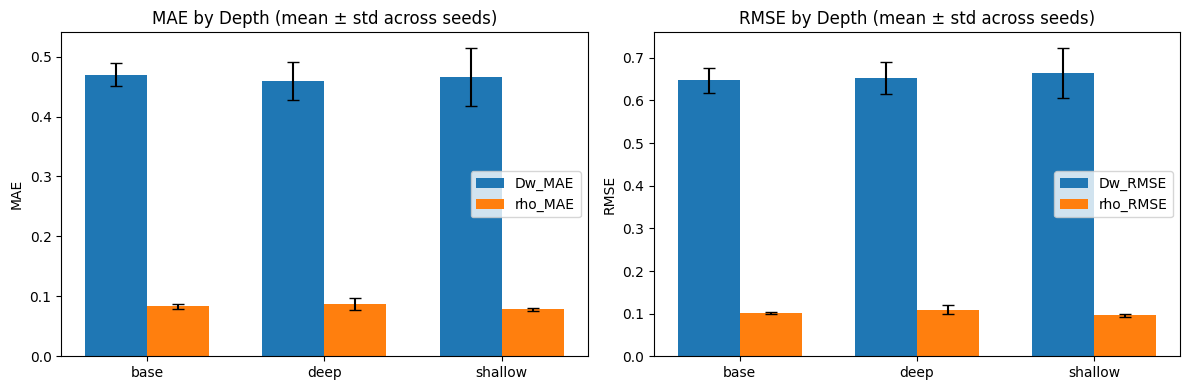

In [8]:
plot_df = summary_df.set_index("depth")

x = np.arange(len(plot_df.index))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE mean +/- std
axes[0].bar(x - width/2, plot_df["Dw_MAE_mean"], width, yerr=plot_df["Dw_MAE_std"], capsize=4, label="Dw_MAE")
axes[0].bar(x + width/2, plot_df["rho_MAE_mean"], width, yerr=plot_df["rho_MAE_std"], capsize=4, label="rho_MAE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df.index)
axes[0].set_title("MAE by Depth (mean ± std across seeds)")
axes[0].set_ylabel("MAE")
axes[0].legend()

# RMSE mean +/- std
axes[1].bar(x - width/2, plot_df["Dw_RMSE_mean"], width, yerr=plot_df["Dw_RMSE_std"], capsize=4, label="Dw_RMSE")
axes[1].bar(x + width/2, plot_df["rho_RMSE_mean"], width, yerr=plot_df["rho_RMSE_std"], capsize=4, label="rho_RMSE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df.index)
axes[1].set_title("RMSE by Depth (mean ± std across seeds)")
axes[1].set_ylabel("RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()